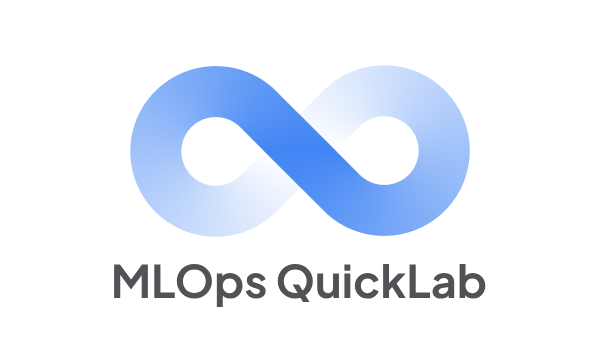

4. Vertex AI 소개 및 개요

In [1]:
# Cell 1
!pip install datasets torch-model-archiver torch-workflow-archiver transformers



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [2]:
# Cell 2
!pip install torch-model-archiver


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [3]:
# Cell 3
# NOTE: model.pth and handler.py are created later in the notebook
# Run this cell AFTER Cell 14 (save model) and Cell 15 (write handler.py)
# Moved to Cell 19 below


In [4]:
# Cell 4
# Colab-specific: not needed in local environment
# from google.colab import drive
# drive.mount('/content/drive')


In [5]:
# Cell 5
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import seaborn as sns

from torch.utils.data import DataLoader
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification
from sklearn.metrics import confusion_matrix
from datasets import load_dataset
from tqdm import tqdm
from typing import TypedDict
import matplotlib.pyplot as plt

/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
# Cell 6
dataset = load_dataset("ag_news")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
optimizer = optim.AdamW(model.parameters(), lr=5e-5)
criterion = torch.nn.CrossEntropyLoss()

class DatasetItem(TypedDict):
    text: str
    label: str


def preprocess_data(dataset_item: DatasetItem) -> dict[str, torch.Tensor]:
    return tokenizer(dataset_item["text"], truncation=True, padding="max_length", return_tensors="pt")


train_dataset = dataset["train"].select(range(1200)).map(preprocess_data, batched=True)
test_dataset = dataset["test"].select(range(800)).map(preprocess_data, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# Cell 7
import os
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

losses: list[float] = []

if os.path.exists("model.pth"):
    print(f"model.pth exists — loading weights, skipping training (device: {device})")
    model.load_state_dict(torch.load("model.pth", map_location=device))
else:
    num_epochs = 3
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
            inputs = {key: batch[key].to(device) for key in batch}
            labels = inputs.pop("label")
            outputs = model(**inputs, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            losses.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        average_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}, Average Loss: {average_loss}")


model.pth exists — loading weights, skipping training (device: mps)


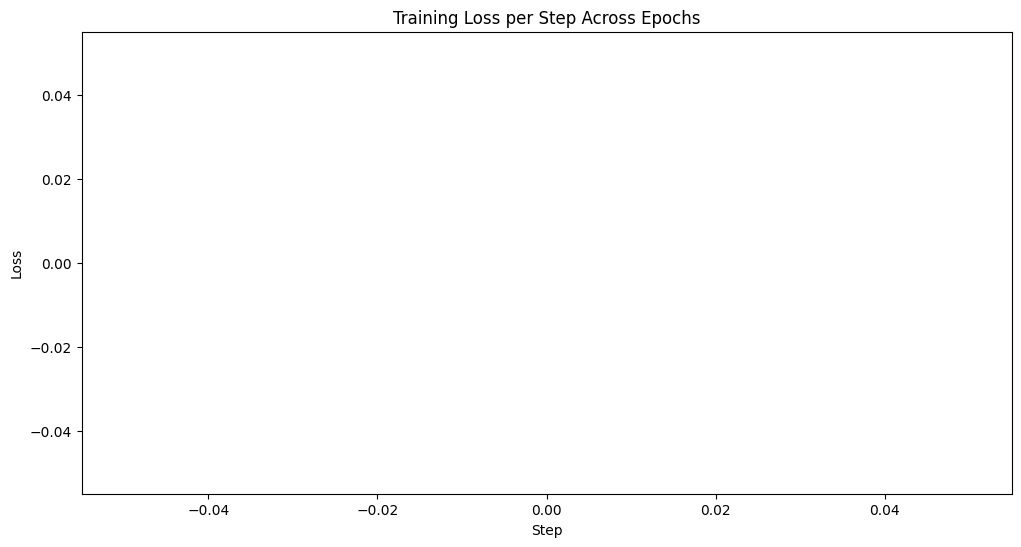

In [8]:
# Cell 8
plt.figure(figsize=(12, 6))
plt.plot(losses, color="#4285f4", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss per Step Across Epochs")
plt.show()

In [9]:
# Cell 9
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)
        correct += (predicted_labels == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating:   1%|          | 1/100 [00:00<00:35,  2.75it/s]

Evaluating:   2%|▏         | 2/100 [00:00<00:25,  3.81it/s]

Evaluating:   3%|▎         | 3/100 [00:00<00:22,  4.29it/s]

Evaluating:   4%|▍         | 4/100 [00:00<00:20,  4.61it/s]

...

Evaluating:  98%|█████████▊| 98/100 [00:19<00:00,  4.77it/s]

Evaluating:  99%|█████████▉| 99/100 [00:19<00:00,  4.83it/s]

Evaluating: 100%|██████████| 100/100 [00:19<00:00,  4.88it/s]

Evaluating: 100%|██████████| 100/100 [00:19<00:00,  5.09it/s]


Test Accuracy: 79.88%


In [10]:
# Cell 10
test_input = "[Official] 'Legendary Coach Resigns → Appoints New Commander' Suwon Completes Coaching Staff... Scout Bae Ki-jong Joins + Coach Shin Hwa-yong Remains"
test_input_processed = tokenizer(test_input, truncation=True, padding="max_length", return_tensors="pt").to(device)
logits = model(**test_input_processed).logits
print(logits)
predicted_labels = torch.argmax(logits, dim=1)

labeling_mapper = ["world", "sports", "business", "sci/tech"]
print(labeling_mapper[predicted_labels[0]])

tensor([[ 2.2839,  2.2674, -2.3523, -1.5844]], device='mps:0',
       grad_fn=<LinearBackward0>)
world


In [11]:
# Cell 11
all_predictions: list[int] = []
all_labels: list[int] = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)

        all_predictions.extend(predicted_labels.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating:   1%|          | 1/100 [00:00<00:19,  4.96it/s]

Evaluating:   2%|▏         | 2/100 [00:00<00:19,  5.06it/s]

Evaluating:   3%|▎         | 3/100 [00:00<00:19,  5.06it/s]

Evaluating:   4%|▍         | 4/100 [00:00<00:19,  5.03it/s]

...

Evaluating:  97%|█████████▋| 97/100 [00:20<00:00,  4.60it/s]

Evaluating:  98%|█████████▊| 98/100 [00:20<00:00,  4.62it/s]

Evaluating:  99%|█████████▉| 99/100 [00:20<00:00,  4.64it/s]

Evaluating: 100%|██████████| 100/100 [00:21<00:00,  4.65it/s]

Evaluating: 100%|██████████| 100/100 [00:21<00:00,  4.72it/s]

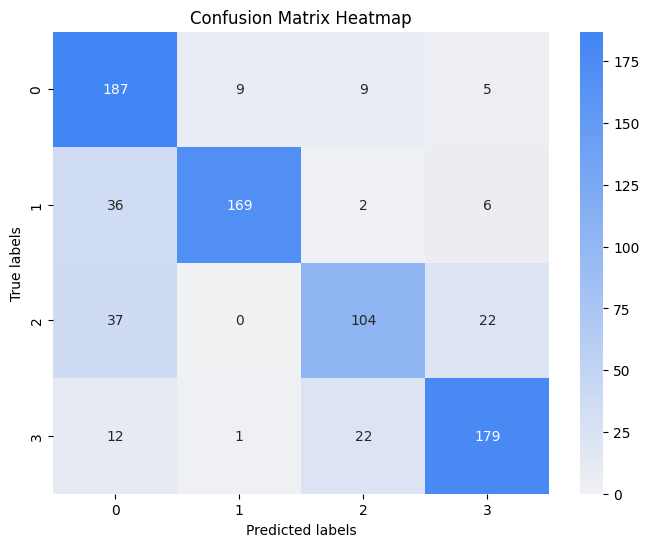

In [12]:
# Cell 12
conf_matrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="g", cmap=sns.light_palette("#4285f4", as_cmap=True))
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

## TorchServe Archive

In [13]:
# Cell 13
# 모델 체크포인트 저장.
model_save_path = "model.pth"
torch.save(model.state_dict(), model_save_path)

In [14]:
# Cell 14
# Write handler.py using Python (%%writefile not available outside Jupyter)
handler_code = 'import json\nimport logging\n\nimport torch\nfrom ts.context import Context\nfrom ts.torch_handler.base_handler import BaseHandler\nfrom transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification\n\nlogging.basicConfig(level=logging.INFO)\n\nclass ModelHandler(BaseHandler):\n    def __init__(self):\n        self.initialized = False\n        self.tokenizer = None\n        self.model = None\n\n    def initialize(self, context: Context):\n        properties = context.system_properties\n        model_dir = properties.get("model_dir")\n        self.initialized = True\n        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")\n        self.model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)\n        model_path = model_dir + "/model.pth"\n        self.model.load_state_dict(torch.load(model_path))\n        self.model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))\n        self.model.eval()\n\n    def preprocess(self, texts: list[str]) -> BatchEncoding:\n        logging.info("preprocess", texts)\n\n        inputs = self.tokenizer(texts, truncation=True, padding=True, max_length=512, return_tensors="pt")\n        device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")\n        return inputs.to(device)\n\n    def inference(self, input_batch: BatchEncoding) -> torch.Tensor:\n        with torch.no_grad():\n            outputs = self.model(**input_batch)\n            logging.info("inference", outputs)\n            return outputs.logits\n\n    def postprocess(self, inference_output: torch.Tensor) -> list[dict[str, float]]:\n        logging.info("postprocess", inference_output)\n\n        probabilities = torch.nn.functional.softmax(inference_output, dim=1)\n        return [{"label": int(torch.argmax(prob)), "probability": float(prob.max())} for prob in probabilities]'
with open("handler.py", "w") as f:
    f.write(handler_code)
print("handler.py written successfully")


handler.py written successfully


In [15]:
# Cell 15
# bert vocab 파일 (아티팩트)

!wget https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt \
    -O bert-base-uncased-vocab.txt

--2026-04-22 17:54:05--  https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 231508 (226K) [text/plain]
Saving to: ‘bert-base-uncased-vocab.txt’

bert-base-uncased-v 100%[===================>] 226.08K  --.-KB/s    in 0.02s   



2026-04-22 17:54:06 (9.82 MB/s) - ‘bert-base-uncased-vocab.txt’ saved [231508/231508]



In [16]:
# Cell 16
# Torch serve archiver의 최종 파일 저장 위치.
# .mar 확장자 파일을 생성하여 패키징 하게 된다.

!mkdir -p model-store

## Register to Vertex AI

In [17]:
# Cell 17
import subprocess, sys, os
if not os.path.exists('model-store/model.mar'):
    result = subprocess.run([
        sys.executable, '-m', 'torch_model_archiver',
        '--model-name', 'model', '--version', '1.0',
        '--serialized-file', 'model.pth',
        '--handler', './handler.py',
        '--extra-files', 'bert-base-uncased-vocab.txt',
        '--export-path', 'model-store', '-f'
    ], capture_output=True, text=True)
    print(result.stdout or result.stderr)
else:
    print("model.mar already exists, skipping archiver")


model.mar already exists, skipping archiver


In [18]:
# Cell 18
# from google.colab import auth
# auth.authenticate_user()

In [19]:
# Cell 19
from google.cloud import storage
from google.cloud import aiplatform
from google.oauth2 import service_account

/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)


/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)


/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.cloud.aiplatform_v1 supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.cloud.aiplatform_v1.
  warnings.warn(message, FutureWarning)


/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.cloud.aiplatform_v1beta1 supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.cloud.aiplatform_v1beta1.
  warnings.warn(message, FutureWarning)
/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.cloud.resourcemanager_v3 supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.cloud.resourcemanager_v3.
  warnings.warn(message, FutureWarning)
/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/google/api_core/

/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.cloud.aiplatform.v1beta1.schema.predict.prediction_v1beta1 supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.cloud.aiplatform.v1beta1.schema.predict.prediction_v1beta1.
  warnings.warn(message, FutureWarning)
/Users/macminim4/Aiffel02/MLOps05/ML05_venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.cloud.aiplatform.v1beta1.schema.trainingjob.definition_v1beta1 supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.cloud.aiplatform.v1beta1.schema.trainingjob.defi

In [20]:
# Cell 20
credentials = service_account.Credentials.from_service_account_file("moonlit-dynamo-492711-n6-39ee9b54e920.json")

In [21]:
# Cell 21
PROJECT_ID = "moonlit-dynamo-492711-n6"                    # @param {type: "string"}
LOCATION = "asia-northeast3"                                       # @param {type: "string"}
BUCKET_NAME = "mlops-quicklab-1"   # @param {type: "string"}
MODEL_FILE_NAME = "model.mar"              # @param {type: "string"}

In [22]:
# Cell 22
storage_client = storage.Client(credentials=credentials)
bucket = storage_client.bucket(BUCKET_NAME)

In [23]:
# Cell 23
def upload_blob(source_file_name: str, destination_blob_name: str) -> None:
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")

In [24]:
# Cell 24
upload_blob("model-store/model.mar", f"models/{MODEL_FILE_NAME}")

File model-store/model.mar uploaded to models/model.mar.


### `torch-model-archiver` 설치 확인

In [25]:
# Cell 25
!which torch-model-archiver
!torch-model-archiver --version

/opt/homebrew/bin/torch-model-archiver


usage: torch-model-archiver [-h] --model-name MODEL_NAME
                            [--serialized-file SERIALIZED_FILE]
                            [--model-file MODEL_FILE] --handler HANDLER
                            [--extra-files EXTRA_FILES]
                            [--runtime {python,python3,LSP}]
                            [--export-path EXPORT_PATH]
                            [--archive-format {tgz,no-archive,zip-store,default}]
                            [-f] -v VERSION [-r REQUIREMENTS_FILE]
                            [-c CONFIG_FILE]
torch-model-archiver: error: argument -v/--version: expected one argument


In [26]:
# Cell 26
!ls -l model-store/

total 792416
-rw-r--r--@ 1 macminim4  staff  405713673 Apr 22 16:24 model.mar


In [27]:
# Cell 27
aiplatform.init(
    project=PROJECT_ID,
    location=LOCATION,
    credentials=credentials,
)

In [28]:
# Cell 28
model_path = f"gs://{BUCKET_NAME}/models"
registry_model = aiplatform.Model.upload(
    display_name="AG News Classification",
    artifact_uri=model_path,
    serving_container_image_uri="asia-northeast3-docker.pkg.dev/moonlit-dynamo-492711-n6/mlops-quicklab/trainer:1.0.3",
    is_default_version=True,
    version_aliases=["v1"],
    version_description="A news category classification model",
    serving_container_predict_route="/predictions/model",
    serving_container_health_route="/ping",
)

Creating Model


Create Model backing LRO: projects/35864400767/locations/asia-northeast3/models/6575602901635301376/operations/1922297619317522432


Model created. Resource name: projects/35864400767/locations/asia-northeast3/models/6575602901635301376@1


To use this Model in another session:


model = aiplatform.Model('projects/35864400767/locations/asia-northeast3/models/6575602901635301376@1')


In [29]:
# Cell 29
DEPLOY_COMPUTE = "n1-standard-4"
DEPLOY_ACCELERATOR = None  # CPU only (T4 GPU quota exceeded)

In [30]:
# Cell 30
endpoint = aiplatform.Endpoint.create(
    display_name="ag-news-category-classification",
    project=PROJECT_ID,
    location=LOCATION,
)

Creating Endpoint


Create Endpoint backing LRO: projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352/operations/5381343608114774016


Endpoint created. Resource name: projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352


To use this Endpoint in another session:


endpoint = aiplatform.Endpoint('projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352')


In [31]:
# Cell 31
deployment = registry_model.deploy(
    endpoint=endpoint,
    machine_type=DEPLOY_COMPUTE,
    min_replica_count=1,
    max_replica_count=1,
    traffic_percentage=100,
    sync=True,
)

Deploying model to Endpoint : projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352


Deploy Endpoint model backing LRO: projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352/operations/5562894968093147136


Endpoint model deployed. Resource name: projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352


In [32]:
# Cell 32
endpoint.predict(instances=[
    "OpenAI releases AI video generator Sora to all customers"
])

Prediction(predictions=[{'output': 'OpenAI releases AI video generator Sora to all customers'}], deployed_model_id='441944300738052096', metadata=None, model_version_id='1', model_resource_name='projects/35864400767/locations/asia-northeast3/models/6575602901635301376', explanations=None)

## Clean up

In [33]:
# Cell 33
endpoint.undeploy_all()
endpoint.delete()

Undeploying Endpoint model: projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352


Undeploy Endpoint model backing LRO: projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352/operations/6715816472699994112


Endpoint model undeployed. Resource name: projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352


Deleting Endpoint : projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352


Endpoint deleted. . Resource name: projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352


Deleting Endpoint resource: projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352


Delete Endpoint backing LRO: projects/35864400767/locations/asia-northeast3/operations/3009916929327497216


Endpoint resource projects/35864400767/locations/asia-northeast3/endpoints/1127881226795876352 deleted.


In [34]:
# Cell 34
registry_model.delete()

Deleting Model : projects/35864400767/locations/asia-northeast3/models/6575602901635301376


Model deleted. . Resource name: projects/35864400767/locations/asia-northeast3/models/6575602901635301376


Deleting Model resource: projects/35864400767/locations/asia-northeast3/models/6575602901635301376


Delete Model backing LRO: projects/35864400767/locations/asia-northeast3/models/6575602901635301376/operations/5981729733438603264


Model resource projects/35864400767/locations/asia-northeast3/models/6575602901635301376 deleted.


In [35]:
# Cell 35
